In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [10]:
df = pd.read_csv("IN-WE_carbon_intensity.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime")

df = df[["datetime", "carbonIntensity"]]

df = df.set_index("datetime")["carbonIntensity"]

df.head()

datetime
2026-08-30 03:00:00+00:00    531
2026-08-30 04:00:00+00:00    486
2026-08-30 05:00:00+00:00    469
2026-08-30 06:00:00+00:00    459
2026-08-30 07:00:00+00:00    465
Name: carbonIntensity, dtype: int64

<b><i><u>Finding d:

In [11]:
raw_p = adfuller(df)[1]
diff1 = df.diff().dropna()
diff2 = diff1.diff().dropna()
diff1_p = adfuller(diff1)[1]
diff2_p = adfuller(diff2)[1]

print("ADF p-value, raw series:", round(raw_p, 4))
print("ADF p-value, differenced once:", round(diff1_p, 6))
print("ADF p-value, differenced twice:", round(diff2_p, 6))

ADF p-value, raw series: 0.0001
ADF p-value, differenced once: 0.0
ADF p-value, differenced twice: 0.0


In [12]:
if raw_p < 0.05:
    d = 0
elif diff1_p < 0.05:
    d = 1
else:
    d = 2

print(f"d = {d}")

d = 0


Raw adf value is 0.0001 which is less than 0.05, so it is stationary, so d = 0

<u><b><i>Finding p and q:</i></b></u>

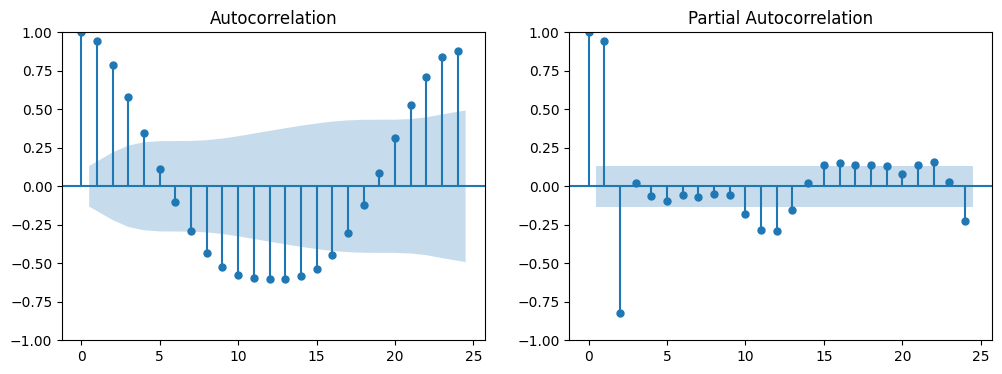

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df, lags=24, ax=axes[0])
plot_pacf(df, lags=24, method="ywm", ax=axes[1])
plt.show()

In [20]:
acf_values, acf_conf = acf(df, nlags=24, alpha=0.05)

acf_df = pd.DataFrame({
    'Lag': np.arange(len(acf_values)),
    'ACF': acf_values, 
    'Lower_CI': acf_conf[:, 0], 
    'Upper_CI': acf_conf[:, 1]
})

print(acf_df.to_string(index=False))

 Lag       ACF  Lower_CI  Upper_CI
   0  1.000000  1.000000  1.000000
   1  0.940802  0.808961  1.072644
   2  0.790701  0.571265  1.010138
   3  0.582971  0.318609  0.847334
   4  0.348497  0.062661  0.634333
   5  0.112370 -0.180759  0.405499
   6 -0.105084 -0.398960  0.188793
   7 -0.289173 -0.583702  0.005356
   8 -0.430201 -0.729624 -0.130778
   9 -0.523658 -0.833639 -0.213677
  10 -0.574119 -0.899113 -0.249125
  11 -0.595147 -0.937317 -0.252978
  12 -0.601971 -0.961684 -0.242258
  13 -0.600438 -0.977255 -0.223621
  14 -0.583133 -0.976229 -0.190037
  15 -0.534985 -0.942840 -0.127130
  16 -0.443369 -0.863244 -0.023493
  17 -0.304288 -0.732225  0.123648
  18 -0.122843 -0.554524  0.308838
  19  0.088881 -0.343407  0.521169
  20  0.312654 -0.119952  0.745260
  21  0.528069  0.091553  0.964585
  22  0.712555  0.265073  1.160037
  23  0.839361  0.372572  1.306149
  24  0.880996  0.388671  1.373321


In [21]:
pacf_values, pacf_conf = pacf(df, nlags=20, alpha=0.05, method='ywm')

pacf_df = pd.DataFrame({
    'Lag': np.arange(len(pacf_values)),
    'PACF': pacf_values, 
    'Lower_CI': pacf_conf[:, 0],
    'Upper_CI': pacf_conf[:, 1]
})

print(pacf_df.to_string(index=False))

 Lag      PACF  Lower_CI  Upper_CI
   0  1.000000  1.000000  1.000000
   1  0.940802  0.808961  1.072644
   2 -0.821707 -0.953548 -0.689866
   3  0.023561 -0.108280  0.155402
   4 -0.065332 -0.197174  0.066509
   5 -0.093839 -0.225681  0.038002
   6 -0.054938 -0.186780  0.076903
   7 -0.068977 -0.200819  0.062864
   8 -0.052195 -0.184037  0.079646
   9 -0.059825 -0.191666  0.072017
  10 -0.182683 -0.314524 -0.050841
  11 -0.284545 -0.416387 -0.152704
  12 -0.291205 -0.423046 -0.159363
  13 -0.155041 -0.286883 -0.023200
  14  0.022090 -0.109751  0.153931
  15  0.138349  0.006507  0.270190
  16  0.152113  0.020272  0.283955
  17  0.138552  0.006711  0.270394
  18  0.136150  0.004309  0.267992
  19  0.131604 -0.000237  0.263446
  20  0.078998 -0.052844  0.210839


In [22]:
acf_sig_lags = [lag for lag in range(1, len(acf_df)) if acf_df.loc[lag, 'Lower_CI'] > 0 or acf_df.loc[lag, 'Upper_CI'] < 0]
pacf_sig_lags = [lag for lag in range(1, len(pacf_df)) if pacf_df.loc[lag, 'Lower_CI'] > 0 or pacf_df.loc[lag, 'Upper_CI'] < 0]

print('Significant ACF lags:', acf_sig_lags)
print('Significant PACF lags:', pacf_sig_lags)

def find_cutoff(df, consecutive=3):
    for lag in range(1, len(df)-consecutive):
        insig = True
        for k in range(lag+1, lag+consecutive+1):
            if df.loc[k, 'Lower_CI'] > 0 or df.loc[k, 'Upper_CI'] < 0:
                insig = False
                break
        if insig:
            return lag
    return 0

p = find_cutoff(acf_df)
q = find_cutoff(pacf_df)

print('\nFinal identified values:')
print(f'p = {p}')
print(f'd = {d}')
print(f'q = {q}')
print(f'\nTherefore, the identified order is (p, d, q) = ({p}, {d}, {q}).')

Significant ACF lags: [1, 2, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15, 16, 21, 22, 23, 24]
Significant PACF lags: [1, 2, 10, 11, 12, 13, 15, 16, 17, 18]

Final identified values:
p = 4
d = 0
q = 2

Therefore, the identified order is (p, d, q) = (4, 0, 2).


<i><u><b>Dataset train and test split

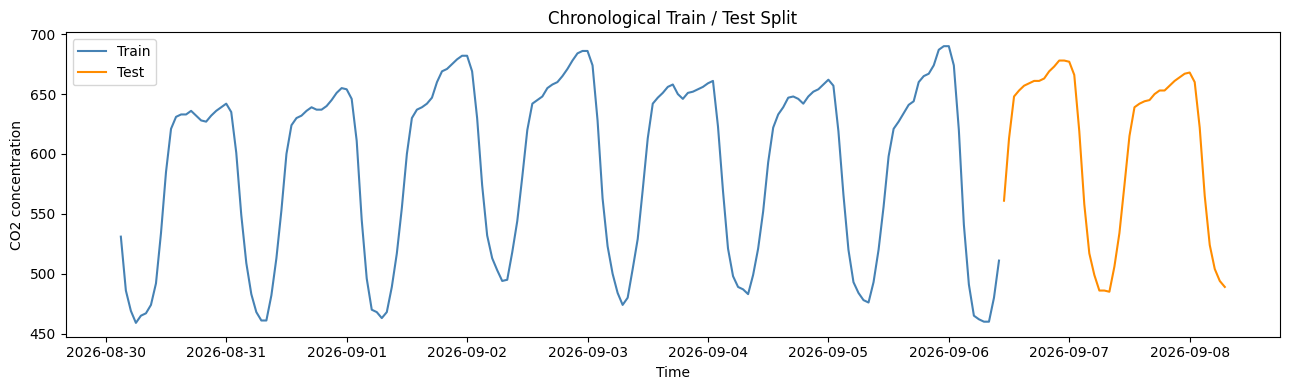

In [23]:
split = int(len(df) * 0.8)

train, test = df.iloc[:split], df.iloc[split:]

plt.figure(figsize=(13, 4))
plt.plot(train, label='Train', color='steelblue')
plt.plot(test, label='Test', color='darkorange')
plt.title('Chronological Train / Test Split')
plt.xlabel('Time')
plt.ylabel('CO2 concentration')
plt.legend()
plt.tight_layout()
plt.show()

<i><u><b>ARIMA model forecasting:


In [27]:
model = ARIMA(train, order=(p, d, q)).fit()

In [28]:
forecast = model.forecast(steps=len(test))
print(model.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        593.7227      3.837    154.717      0.000     586.201     601.244
ar.L1          2.7535      0.162     16.985      0.000       2.436       3.071
ar.L2         -2.9688      0.449     -6.611      0.000      -3.849      -2.089
ar.L3          1.5332      0.454      3.376      0.001       0.643       2.423
ar.L4         -0.3542      0.167     -2.118      0.034      -0.682      -0.027
ma.L1         -0.5823      0.177     -3.281      0.001      -0.930      -0.234
ma.L2         -0.2481      0.179     -1.389      0.165      -0.598       0.102
sigma2        79.6825     10.113      7.879      0.000      59.862      99.503


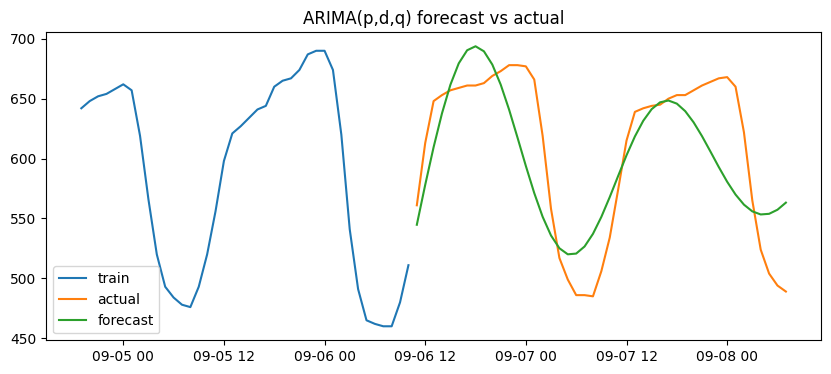

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(train.index[-40:], train.values[-40:], label="train")
plt.plot(test.index, test.values, label="actual")
plt.plot(test.index, forecast.values, label="forecast")
plt.legend()
plt.title(f"ARIMA(p,d,q) forecast vs actual")
plt.show()

The forecast tracks the seasonality, but seem off otherwise

In [31]:
mae = np.mean(np.abs(forecast.values - test.values))
rmse = np.sqrt(np.mean((forecast.values - test.values) ** 2))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("Test period mean:", round(test.mean(), 1))

MAE: 35.26
RMSE: 43.85
Test period mean: 608.8
